ファイルをアップロードした後、最初のコードセル `1joLYqf61Tx7` の `file_path` を更新して、新しいパスを指すようにしてください。例えば、上記の「方法1」でアップロードした場合は、`file_path = 'monthly_in_situ_co2_mlo.csv'` のままで大丈夫です。もし「方法2」でGoogle Driveに保存した場合は、上記コードのコメントアウトされた行のように `file_path` を変更してください。

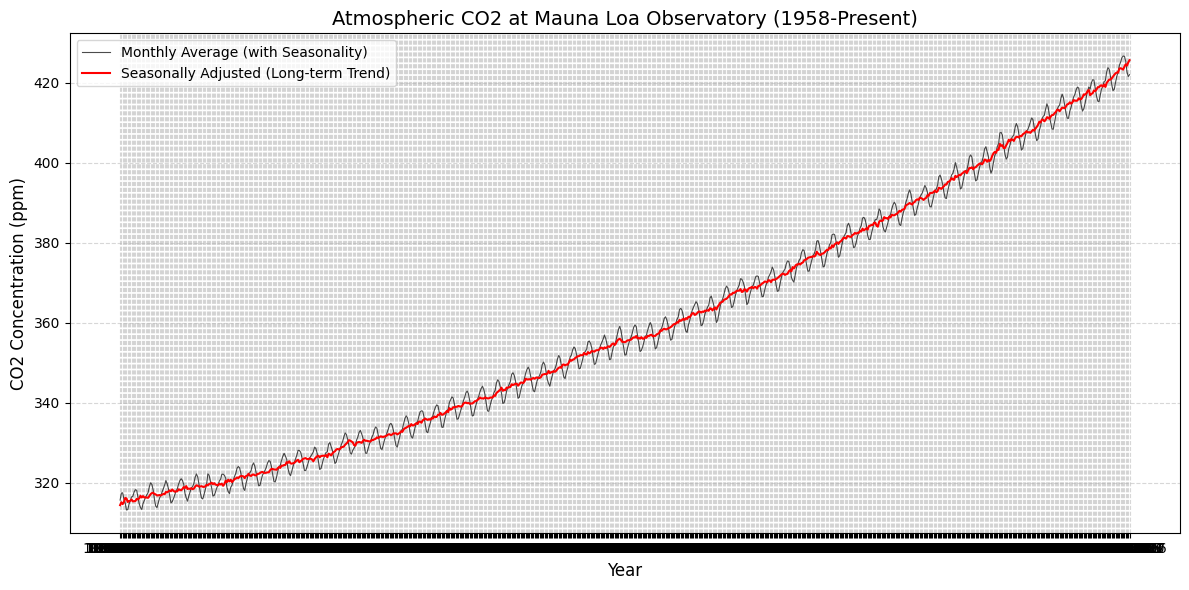

--- 最新の観測データ ---
         Yr  Mn     CO2  Seasonally_Adjusted
800  2024.0  06  426.62               424.06
801  2024.0  07  425.40               424.63
802  2024.0  08  422.70               424.30
803  2024.0  09  421.59               425.11
804  2024.0  10  422.05               425.66


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CSVファイルの読み込み
# monthly_in_situ_co2_mlo.csv は最初の約60行が説明文（"で始まる行）です。
# comment='"' を指定することで、それらを自動的にスキップできます。
file_path = 'monthly_in_situ_co2_mlo.csv'

try:
    df = pd.read_csv(
        file_path,
        comment='"',           # " で始まるコメント行を無視
        header=None,           # カラム名が定義されていない行から読み込む
        skiprows=9,            # 最初の6行 + 3行の記述ヘッダーをスキップ
        usecols=range(9),      # 最初の9列のみを使用
        skipinitialspace=True, # カンマ後の余計な空白を削除
        na_values=['-99.99']   # -99.99をNaNとして扱う
    )

    # 2. カラム名の設定（スクリップス海洋研究所の公式フォーマットに準拠）
    # 0:年, 1:月, 2:Excel形式日付, 3:小数点形式日付, 4:CO2濃度, 5:季節調整済み ...
    df.columns = [
        'Yr', 'Mn', 'Date_Excel', 'Date_Decimal', 'CO2',
        'Seasonally_Adjusted', 'Fit', 'Seasonally_Adjusted_Fit', 'Station'
    ]

    # CO2とSeasonally_Adjusted列を数値型に変換し、変換できない値はNaNにする
    df['CO2'] = pd.to_numeric(df['CO2'], errors='coerce')
    df['Seasonally_Adjusted'] = pd.to_numeric(df['Seasonally_Adjusted'], errors='coerce')
    # 'Yr'列を数値型に変換
    df['Yr'] = pd.to_numeric(df['Yr'], errors='coerce')


    # 3. 欠損値の処理
    # CO2濃度が正の値の行のみを抽出します (NaNや0以下の値を除外)
    df = df[df['CO2'] > 0]

    # 4. 可視化
    plt.figure(figsize=(12, 6))

    # 月次データ（季節変動を含む「生の呼吸」）
    plt.plot(df['Date_Decimal'], df['CO2'],
             color='black', linewidth=0.8, alpha=0.7, label='Monthly Average (with Seasonality)')

    # 季節調整済みデータ（長期的な上昇トレンド）
    plt.plot(df['Date_Decimal'], df['Seasonally_Adjusted'],
             color='red', linewidth=1.5, label='Seasonally Adjusted (Long-term Trend)')

    # グラフの整形
    plt.title('Atmospheric CO2 at Mauna Loa Observatory (1958-Present)', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('CO2 Concentration (ppm)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 最新の5ヶ月分を表示してデータを確認
    print("--- 最新の観測データ ---")
    print(df.tail(5)[['Yr', 'Mn', 'CO2', 'Seasonally_Adjusted']])

except FileNotFoundError:
    print(f"エラー: {file_path} が見つかりません。左側のフォルダアイコンからアップロードされているか確認してください。")

In [7]:
# 5. CO2濃度の年次平均を計算
annual_avg_co2 = df.groupby('Yr')['CO2'].mean().reset_index()

print("--- CO2濃度の年次平均 ---")
print(annual_avg_co2.tail(10))


--- CO2濃度の年次平均 ---
        Yr         CO2
57  2015.0  400.867500
58  2016.0  404.207500
59  2017.0  406.515833
60  2018.0  408.527500
61  2019.0  411.424167
62  2020.0  413.947500
63  2021.0  416.113333
64  2022.0  418.216667
65  2023.0  420.773333
66  2024.0  424.354000


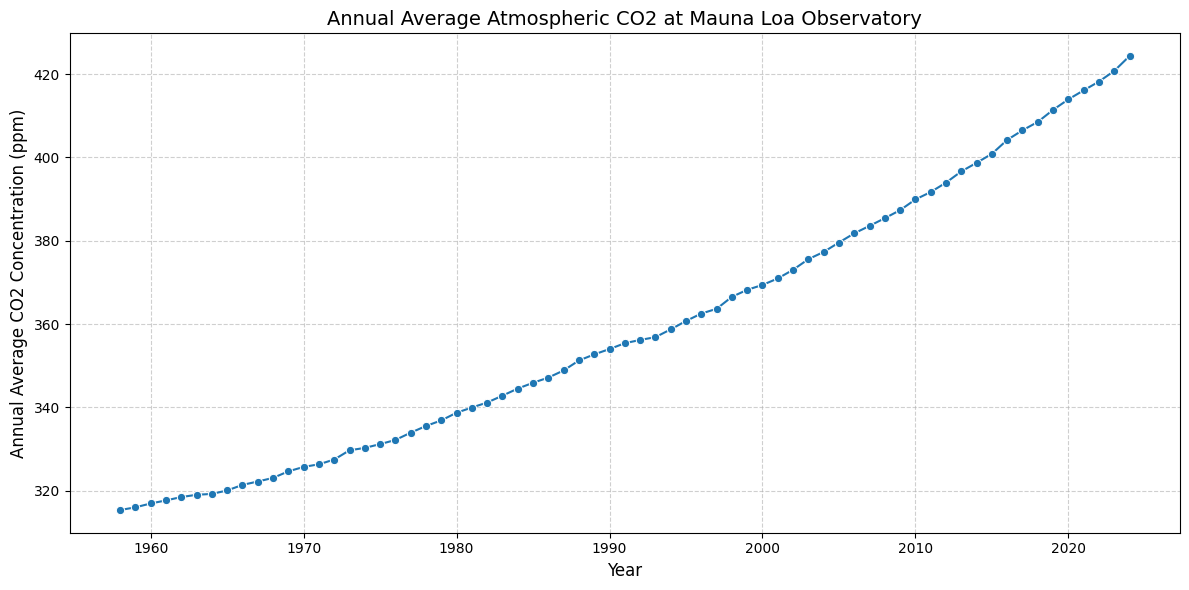

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 6. 年次平均CO2濃度の可視化
plt.figure(figsize=(12, 6))
sns.lineplot(x='Yr', y='CO2', data=annual_avg_co2, marker='o')
plt.title('Annual Average Atmospheric CO2 at Mauna Loa Observatory', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual Average CO2 Concentration (ppm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

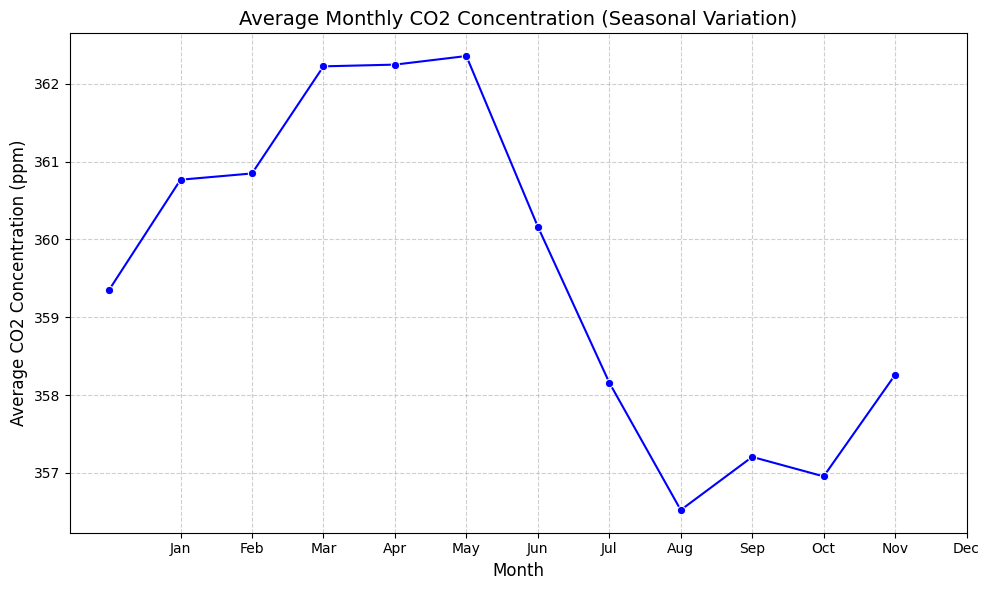

--- CO2濃度の月次平均 ---
    Mn         CO2
0   01  359.351364
1   02  360.767692
2   03  360.848182
3   04  362.224394
4   05  362.246418
5   06  362.356818
6   07  360.165373
7   08  358.160896
8   09  356.523731
9   10  357.206212
10  11  356.955909
11  12  358.260606


In [9]:
# 7. CO2濃度の月次平均を計算し、季節変動を可視化
# 月ごとの平均CO2濃度を計算
monthly_avg_co2 = df.groupby('Mn')['CO2'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Mn', y='CO2', data=monthly_avg_co2, marker='o', color='blue')
plt.title('Average Monthly CO2 Concentration (Seasonal Variation)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average CO2 Concentration (ppm)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("--- CO2濃度の月次平均 ---")
print(monthly_avg_co2)

### 8. 期間を3つに分割し、それぞれの期間における平均の季節変動をプロット

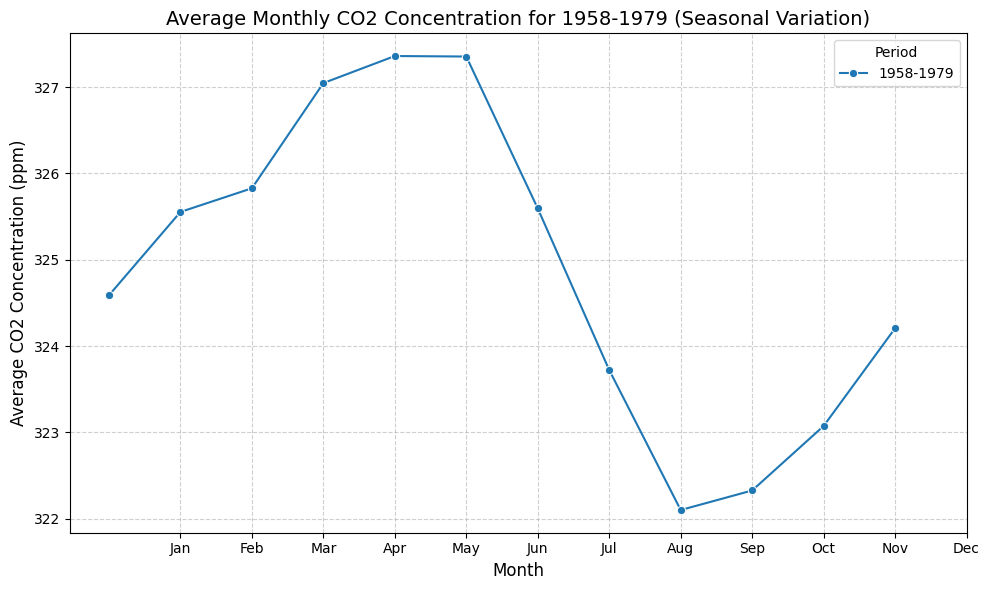

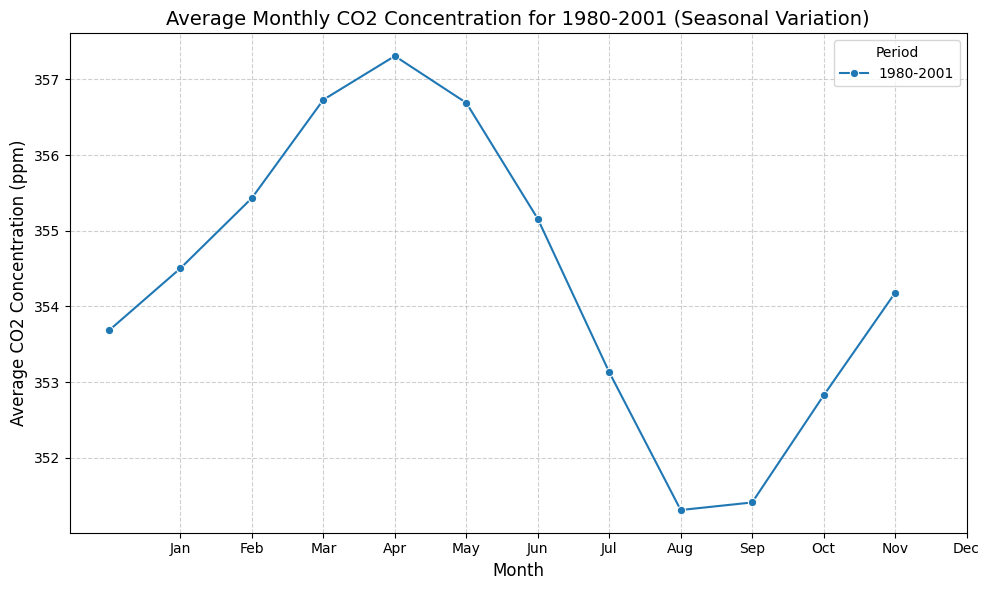

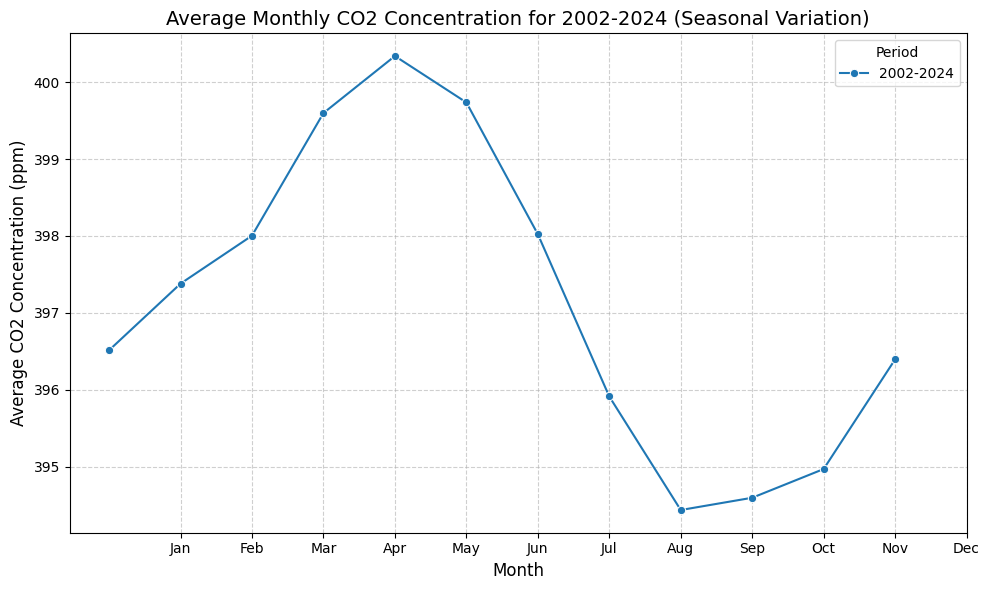

In [10]:
periods = [
    {'name': '1958-1979', 'start_year': 1958, 'end_year': 1979},
    {'name': '1980-2001', 'start_year': 1980, 'end_year': 2001},
    {'name': '2002-2024', 'start_year': 2002, 'end_year': 2024}
]

for period in periods:
    plt.figure(figsize=(10, 6)) # Create a new figure for each period

    # 各期間のデータをフィルタリング
    df_period = df[(df['Yr'] >= period['start_year']) & (df['Yr'] <= period['end_year'])]

    # 月ごとの平均CO2濃度を計算
    monthly_avg_co2_period = df_period.groupby('Mn')['CO2'].mean().reset_index()

    # プロット
    sns.lineplot(x='Mn', y='CO2', data=monthly_avg_co2_period, marker='o', label=period['name'])

    plt.title(f'Average Monthly CO2 Concentration for {period['name']} (Seasonal Variation)', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average CO2 Concentration (ppm)', fontsize=12)
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Period')
    plt.tight_layout()
    plt.show()